In [181]:
import os

import polars as pl
import seaborn as sns
from matplotlib import pyplot as plt, rcParams
import synapseclient
from scipy import stats
import numpy as np

rcParams["font.family"] = "Arial"
rcParams["font.size"] = 7

In [2]:
# Jupyter server should be running from src/python
# assumes auth_token.txt exists in src/python as described in setup instructions
AUTH_TOKEN = os.path.abspath("auth_token.txt")

# synapse ID for the combined data table
COMBINED_TABLE_SYN_ID = "syn74775996"

# synapse IDs for the subset data
SUBSET_DATA_SYN_IDS = {
    "B_FLT3-ITDxNPM1-WT.arrow": "syn74776644",
    "B_FLT3-ITDxNPM1-WT.csv": "syn74776636",
    "B_FLT3-ITDxNPM1-WT_mut-cols.txt": "syn74776633",
    "B_FLT3-ITDxNPM1-WT_wt-cols.txt": "syn74776632",
    "B_NPM1-WT.arrow": "syn74776645",
    "B_NPM1-WT.csv": "syn74776649",
    "B_NPM1-WT_mut-cols.txt": "syn74776642",
    "B_NPM1-WT_wt-cols.txt": "syn74776643",
    "W_FLT3-ITDxNPM1-WT.arrow": "syn74776658",
    "W_FLT3-ITDxNPM1-WT.csv": "syn74776663",
    "W_FLT3-ITDxNPM1-WT_mut-cols.txt": "syn74776650",
    "W_FLT3-ITDxNPM1-WT_wt-cols.txt": "syn74776653",
    "W_NPM1-WT.arrow": "syn74776666",
    "W_NPM1-WT.csv": "syn74776667",
    "W_NPM1-WT_mut-cols.txt": "syn74776659",
    "W_NPM1-WT_wt-cols.txt": "syn74776660",
}

# directory for figures
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_figures",
    "hox"
)

In [3]:
# ensure figure directory exists
os.makedirs(FIGURE_DIR, exist_ok=True)

In [6]:
with open(AUTH_TOKEN, "r") as atf:
    SYN = synapseclient.login(authToken=atf.read())


UPGRADE AVAILABLE

A more recent version of the Synapse Client (4.12.0) is available. Your version (4.11.0) can be upgraded by typing:
   pip install --upgrade synapseclient

Python Synapse Client version 4.12.0 release notes

https://python-docs.synapse.org/news/


Welcome, dylan.ross!



---

In [160]:
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    b_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    b_mut_cols = mutf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    w_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    w_mut_cols = mutf.read().split("\n")

df = (
    pl.concat(
        [
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)
        ], 
        how="diagonal"
    )
    .filter(pl.col("Block") == "Transcriptomics")
    .drop("Block")
    .rename({"Feature": "Gene"})
    .filter(
        pl.col("Gene").is_in(hox)
    )
    .unpivot(
            index="Gene",
            variable_name="Sample",
            value_name="Z-score"
        )
        .with_columns(
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "WT"
                        for k in w_wt_cols + b_wt_cols
                    } | {
                        k: "NPM1"
                        for k in w_mut_cols + b_mut_cols
                    }
                )
                .alias("Mutation")
            ),
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "black"
                        for k in b_wt_cols + b_mut_cols
                    } | {
                        k: "white"
                        for k in w_wt_cols + w_mut_cols
                    }
                )
                .alias("Race")
            )
        )
)
df

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_45920/780659023.py:1: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



KeyboardInterrupt: 

---

In [141]:
df_pan = (
    df
    .drop("Sample")
    .pivot(
        on=["Mutation", "Race"],
        values="Z-score",
        aggregate_function="mean",
    )
    .rename({
        '{"WT","black"}': "(black) NPM1-",
        '{"WT","white"}': "(white) NPM1-",
        '{"NPM1","black"}': "(black) NPM1+",
        '{"NPM1","white"}': "(white) NPM1+"
    })
    .to_pandas()
    .set_index("Gene")
)

In [ ]:
row_colors = [
    {
        # HOXA cluster (myeloid-relevant members)
        **dict.fromkeys(["HOXA5", "HOXA6", "HOXA7", "HOXA8", "HOXA9", "HOXA10"], "#E07856"),
        # HOXB cluster (HSC/progenitor-relevant members)
        **dict.fromkeys(["HOXB3", "HOXB4", "HOXB5", "HOXB6"], "#5BA3B5"),
        # TALE-family HOX cofactors
        **dict.fromkeys(["MEIS1", "PBX3"], "#8B6FB0"),
        # Upstream epigenetic regulators of HOX expression
        #**dict.fromkeys(["KMT2A", "MEN1", "DOT1L"], "#41C7E5"),
        # Key direct downstream effector
        #**dict.fromkeys(["MEF2C"], "#7CE72A"),
        
    }[_]
    for _ in df_pan.index
]

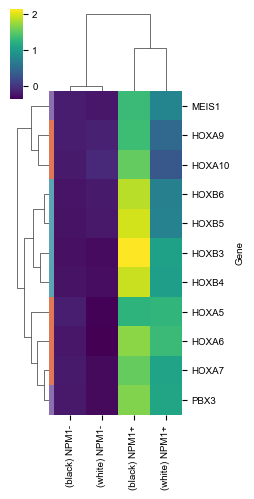

In [148]:
sns.clustermap(
    df_pan,
    row_colors=row_colors,
    cmap="viridis",
    figsize=(2.5, 5),
)
plt.savefig(
    os.path.join(FIGURE_DIR, "hox_heatmap.pdf"),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()

In [477]:
df_pan_all = (
    df
    .pivot(
        on="Sample",
        values="Z-score",
        index="Gene",
        aggregate_function="mean"
    )
    .to_pandas()
    .set_index("Gene")
    .fillna(0)
)

In [478]:
row_colors_all = [
    {
        # HOXA cluster (myeloid-relevant members)
        **dict.fromkeys(["HOXA5", "HOXA6", "HOXA7", "HOXA8", "HOXA9", "HOXA10"], "#E07856"),
        # HOXB cluster (HSC/progenitor-relevant members)
        **dict.fromkeys(["HOXB3", "HOXB4", "HOXB5", "HOXB6"], "#5BA3B5"),
        # TALE-family HOX cofactors
        **dict.fromkeys(["MEIS1", "PBX3"], "#8B6FB0"),
        # Upstream epigenetic regulators of HOX expression
        #**dict.fromkeys(["KMT2A", "MEN1", "DOT1L"], "#41C7E5"),
        # Key direct downstream effector
        #**dict.fromkeys(["MEF2C"], "#7CE72A"),
        
    }[_]
    for _ in df_pan_all.index
]

In [503]:
col_colors_all_race = [
    {
        **dict.fromkeys(w_wt_cols + w_mut_cols, "#FFFFFF"),
        **dict.fromkeys(b_wt_cols + b_mut_cols, "#000000")
    }[_]
    for _ in df_pan_all.columns
]
col_colors_all_mut = [
    {
        **dict.fromkeys(w_wt_cols + b_wt_cols, "#0000FF"),
        **dict.fromkeys(w_mut_cols + b_mut_cols, "#FF0000")
    }[_]
    for _ in df_pan_all.columns
]

In [479]:
df_pan_all

,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,...,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092
Gene,,,,,,,,,,,,,,,,,,,,,
HOXA9,0.0,-0.645247,-0.559828,-0.565021,1.099603,0.0,0.598109,-0.414856,0.0,-0.699564,...,-0.526425,0.0,0.201401,1.583215,0.267690,0.744078,0.690646,0.648858,-0.226764,0.548705
HOXA5,0.0,-0.586376,-0.530936,-0.537601,0.182570,0.0,-0.250397,-0.223904,0.0,-0.632566,...,-0.568677,0.0,1.178336,2.481519,0.938813,0.651106,2.533476,0.892164,0.132246,1.391038
HOXA6,0.0,-0.616997,-0.622770,-0.568157,-0.632846,0.0,-0.131829,-0.460671,0.0,-0.629393,...,-0.659462,0.0,0.743474,3.060570,0.888514,0.506148,0.922840,1.161303,0.281592,1.989530
HOXB6,0.0,-0.356400,-0.345407,-0.291161,-0.375054,0.0,-0.332528,-0.375054,0.0,-0.373023,...,-0.650179,0.0,0.416453,1.250428,0.395143,0.586550,2.287882,2.209776,0.965177,-0.024201
HOXB5,0.0,-0.394854,-0.127656,-0.273143,-0.403609,0.0,-0.403609,-0.403609,0.0,-0.370234,...,-0.642218,0.0,1.077906,1.034942,0.716629,1.260882,3.411938,3.275636,0.326527,0.251876
HOXB3,0.0,-0.383428,0.049939,-0.227144,0.551684,0.0,-0.384855,-0.370344,0.0,-0.381830,...,-0.646386,0.0,1.127757,2.804525,0.704490,0.243787,0.877954,2.896672,0.330788,0.969057
HOXA7,0.0,-0.593458,-0.517910,-0.428658,-0.609687,0.0,-0.117641,-0.408122,0.0,-0.609687,...,-0.779300,0.0,1.148612,2.709936,0.017647,0.384379,0.154546,1.577342,0.480216,1.837458
MEIS1,0.0,-0.507222,0.867091,-0.527276,-0.031441,0.0,-0.294201,-0.434329,0.0,-0.559910,...,-0.818286,0.0,0.426970,2.277828,0.498398,2.176008,-0.093494,3.701055,-0.293330,1.576619
PBX3,0.0,-0.232561,-0.319872,-0.596253,-0.200403,0.0,-0.423903,-0.478215,0.0,-0.407787,...,-0.646582,0.0,1.079264,2.420601,0.832965,1.342681,1.314601,1.115584,0.769942,2.723321


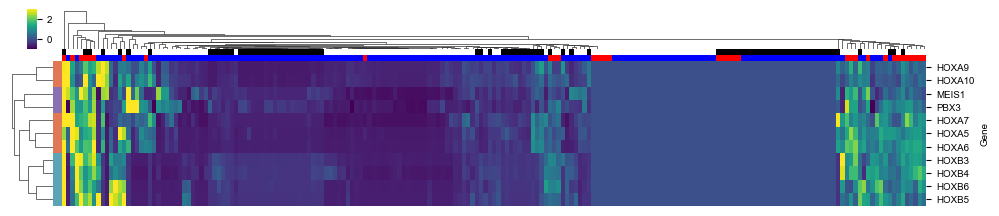

In [516]:
cg = sns.clustermap(
    df_pan_all,
    row_colors=row_colors_all,
     col_colors=[
        col_colors_all_race,
        col_colors_all_mut
    ],
    cmap="viridis",
    figsize=(10, 3),
    vmax=3
)

cg.ax_heatmap.set_xticks([])
cg.gs.set_width_ratios([0.5, 0.1, 10])
cg.ax_cbar.set_aspect("equal")

plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig(
    os.path.join(FIGURE_DIR, "hox_heatmap_all.pdf"),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()

---

In [223]:
combined = pl.read_ipc(SYN.get(COMBINED_TABLE_SYN_ID).path)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_45920/3275196554.py:1: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  combined = pl.read_ipc(SYN.get(COMBINED_TABLE_SYN_ID).path)


[syn74775996:combined_omics_data.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/712/172719712/combined_omics_data.arrow, skipping download.


In [239]:
df2 = (
    combined
    .filter(pl.col("Block") == "Transcriptomics")
    .drop("Block")
    .rename({"Feature": "Gene"})
    .filter(
        pl.col("Gene").is_in(hox2)
    )
    .unpivot(
            index="Gene",
            variable_name="Sample",
            value_name="TPM"
    )
    .filter(
        pl.col("Sample")
        .is_in(w_wt_cols + b_wt_cols + w_mut_cols + b_mut_cols)
    )
    .with_columns(
        # add mutation label
        (
            pl.col("Sample")
            .replace(
                {
                    k: "WT"
                    for k in w_wt_cols + b_wt_cols
                } | {
                    k: "NPM1"
                    for k in w_mut_cols + b_mut_cols
                }
            )
            .alias("Mutation")
        ),
        # add race label
        (
            pl.col("Sample")
            .replace(
                {
                    k: "black"
                    for k in b_wt_cols + b_mut_cols
                } | {
                    k: "white"
                    for k in w_wt_cols + w_mut_cols
                }
            )
            .alias("Race")
        )
    )
)
df2

Gene,Sample,TPM,Mutation,Race
str,str,f64,str,str
"""HOXA9""","""12-00127""",null,"""NPM1""","""white"""
"""HOXA5""","""12-00127""",null,"""NPM1""","""white"""
"""HOXA6""","""12-00127""",null,"""NPM1""","""white"""
"""HOXB6""","""12-00127""",null,"""NPM1""","""white"""
"""HOXB5""","""12-00127""",null,"""NPM1""","""white"""
…,…,…,…,…
"""HOXA7""","""17-00881-Bridge""",null,"""WT""","""white"""
"""MEIS1""","""17-00881-Bridge""",null,"""WT""","""white"""
"""PBX3""","""17-00881-Bridge""",null,"""WT""","""white"""


In [240]:
tpm = (
    df2
    .filter(pl.col("TPM").is_not_null())
    .group_by("Gene", "Race", "Mutation")
    .agg("TPM")
)
tpm

Gene,Race,Mutation,TPM
str,str,str,list[f64]
"""PBX3""","""black""","""WT""","[14.741046, 11.349057, … 7.924873]"
"""HOXB3""","""black""","""WT""","[0.411867, 17.609783, … 2.909742]"
"""HOXB5""","""white""","""WT""","[0.0, 0.0, … 0.0]"
"""PBX3""","""white""","""NPM1""","[74.078446, 79.605709, … 140.326442]"
"""HOXA6""","""black""","""WT""","[0.331537, 0.210763, … 1.789935]"
…,…,…,…
"""HOXB6""","""white""","""NPM1""","[0.068545, 36.26365, … 15.414824]"
"""HOXA7""","""white""","""NPM1""","[23.506159, 58.007995, … 49.232117]"
"""HOXA6""","""black""","""NPM1""","[52.095532, 19.884976, … 51.187523]"


---

In [275]:
def swarm(
    ax,
    x_center, 
    values,
    c
):
    x = np.random.normal(x_center, 0.02, size=len(values))
    ax.scatter(
        x, 
        values,
        marker=".",
        s=1,
        c=c
    )

In [403]:
C = {
    "swarm": {
        ("black", "WT"): "#7D7B8D",
        ("black", "NPM1"): "#F3858E",
        ("black", "NPM1+FLT3_ITD"): "#F3858E",
        ("white", "WT"): "#81B0F2",
        ("white", "NPM1"): "#EFDA85",
        ("white", "NPM1+FLT3_ITD"): "#EFDA85",
    },
    "bar": {
        ("black", "WT"): "#53516A",
        ("black", "NPM1"): "#E84855",
        ("black", "NPM1+FLT3_ITD"): "#E84855",
        ("white", "WT"): "#3185FC",
        ("white", "NPM1"): "#E3B505",
        ("white", "NPM1+FLT3_ITD"): "#E3B505",
    }
}

---

In [436]:
hox2 = [
    # HOXA cluster (myeloid-relevant members)
    "HOXA5", "HOXA6", "HOXA7", "HOXA9", "HOXA10",
    # HOXB cluster (HSC/progenitor-relevant members)
    "HOXB3", "HOXB4", "HOXB5", "HOXB6",
    # TALE-family HOX cofactors
    "MEIS1", "PBX3",
]

In [437]:
zscores = (
    df
    .filter(pl.col("Z-score").is_not_null())
    .group_by("Gene", "Race", "Mutation")
    .agg("Z-score")
)
zscores

Gene,Race,Mutation,Z-score
str,str,str,list[f64]
"""HOXA9""","""black""","""NPM1""","[1.944144, 0.76494, … 1.348805]"
"""MEIS1""","""black""","""WT""","[-0.507222, 0.867091, … -0.510578]"
"""MEIS1""","""white""","""WT""","[-0.846266, -0.846535, … -0.835274]"
"""HOXA10""","""black""","""WT""","[-0.645833, -0.485944, … -0.537168]"
"""HOXA9""","""black""","""WT""","[-0.645247, -0.559828, … -0.61495]"
…,…,…,…
"""HOXA7""","""black""","""WT""","[-0.593458, -0.51791, … -0.392469]"
"""HOXA10""","""white""","""NPM1""","[0.656526, 0.446137, … 0.206781]"
"""HOXB6""","""white""","""NPM1""","[-0.650506, 0.826672, … -0.024201]"


In [438]:
zsf = {
    (g, r, m): z
    for g, r, m, z in zscores.iter_rows()
}

In [439]:
pvf = {}
for gene in hox2:
    for race in ["black", "white"]:
        if (
            (zs_wt := zsf.get((gene, race, "WT"))) is not None 
            and (zs_mut := zsf.get((gene, race, "NPM1"))) is not None
        ):
            pvf[(gene, race)] = stats.ttest_ind(zs_wt, zs_mut, equal_var=False).pvalue

In [440]:
# apply BH correction to ttest pvalues
pvf_keys, pvf_values = map(list, zip(*pvf.items()))
pvf = dict(zip(pvf_keys, stats.false_discovery_control(pvf_values)))


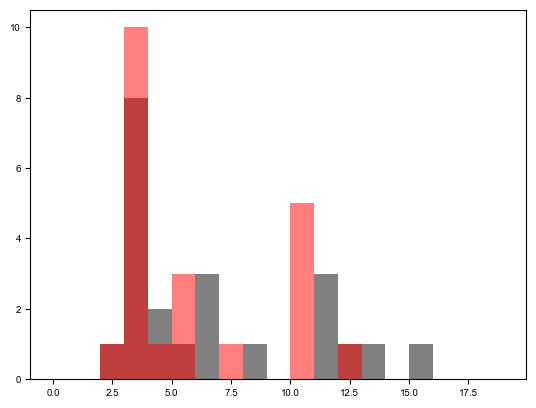

In [441]:
plt.hist(-np.log(pvf_values), bins=range(20), color="grey")
plt.hist(-np.log(stats.false_discovery_control(pvf_values)), bins=range(20), color="r", alpha=0.5)
plt.show()
plt.close()

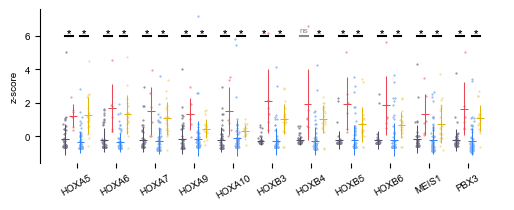

In [442]:
fig, ax = plt.subplots(
    figsize=(6, 2)
)

x_off = 0.2
bw = 0.1

#ax.axhline(c="k", lw=1., zorder=-1)

for x_center, gene in enumerate(hox2):
    x_center = x_center + 1 - 1.5 * x_off
    for race in ["black", "white"]:
        for mut in ["WT", "NPM1"]:
            if (zs := zsf.get((gene, race, mut))) is not None:
                ax.errorbar(
                    x_center,
                    np.mean(zs),
                    yerr=np.std(zs),
                    xerr=bw,
                    ecolor=C["bar"][(race, mut)],
                    elinewidth=0.75
                )
                # ax.scatter(
                #     x_center,
                #     np.mean(zs),
                #     marker="_",
                #     s=12,
                #     c="k",
                # )
                swarm(ax, x_center, zs, C["swarm"][(race, mut)])
            x_center += x_off
        # annotate statistically significant comparisons between WT and mutant
        bc = "#898989"
        t = "ns"
        t_yoff = 0.2
        fs = 6
        fw = "normal"
        if (pv := pvf.get((gene, race))) is not None and pv <= 0.05:
            t = "*"
            bc = "k"
            t_yoff = 0
            fs = 8
            fw = "bold"
        ax.text(
            x_center - 1.5 * x_off,
            6 + t_yoff,
            t,
            color=bc,
            ha="center",
            fontsize=fs,
            fontweight=fw
        )
        ax.plot(
            [x_center - 2 * x_off, x_center - x_off],
            [6, 6],
            c=bc,
            ls="-",
            lw=1.5
        )


for d in ["top", "right", "bottom"]:
    ax.spines[d].set_visible(False)

ax.set_xticks([_ + 1 for _ in range(len(hox2))])
ax.set_xticklabels(hox2, rotation=30)

ax.set_ylabel("z-score")
plt.savefig(
    os.path.join(FIGURE_DIR, "z_score_bar_swarms.png"),
    dpi=400,
    transparent=True,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [545]:
hox2_prot = [
    # HOXA cluster (myeloid-relevant members)
    "HOXA10",
    # HOXB cluster (HSC/progenitor-relevant members)
    "HOXB4",
    # TALE-family HOX cofactors
    "MEIS1", "PBX3",
    # differentiation markers
    "PROM1", "CD34", #"FLT3", "CEBPA", "CEBPE"
]

In [546]:
df_prot = (
    pl.concat(
        [
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)
        ], 
        how="diagonal"
    )
    .filter(pl.col("Block") == "Proteomics")
    .drop("Block")
    .rename({"Feature": "Gene"})
    .filter(
        pl.col("Gene").is_in(hox2_prot)
    )
    .unpivot(
            index="Gene",
            variable_name="Sample",
            value_name="Z-score"
        )
        .with_columns(
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "WT"
                        for k in w_wt_cols + b_wt_cols
                    } | {
                        k: "NPM1"
                        for k in w_mut_cols + b_mut_cols
                    }
                )
                .alias("Mutation")
            ),
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "black"
                        for k in b_wt_cols + b_mut_cols
                    } | {
                        k: "white"
                        for k in w_wt_cols + w_mut_cols
                    }
                )
                .alias("Race")
            )
        )
)
df_prot

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_45920/3243669642.py:4: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),


[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_45920/3243669642.py:5: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)


[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


Gene,Sample,Z-score,Mutation,Race
str,str,f64,str,str
"""CD34""","""14-00240""",-1.159391,"""WT""","""black"""
"""HOXA10""","""14-00240""",-0.831058,"""WT""","""black"""
"""HOXB4""","""14-00240""",-1.372715,"""WT""","""black"""
"""MEIS1""","""14-00240""",-1.000057,"""WT""","""black"""
"""PBX3""","""14-00240""",-1.325229,"""WT""","""black"""
…,…,…,…,…
"""HOXA10""","""19-00092""",0.714608,"""NPM1""","""white"""
"""HOXB4""","""19-00092""",-0.873711,"""NPM1""","""white"""
"""MEIS1""","""19-00092""",0.378671,"""NPM1""","""white"""


In [547]:
zscores_prot = (
    df_prot
    .filter(pl.col("Z-score").is_not_null())
    .group_by("Gene", "Race", "Mutation")
    .agg("Z-score")
)
zscores_prot

Gene,Race,Mutation,Z-score
str,str,str,list[f64]
"""PROM1""","""white""","""NPM1""","[0.451769, 0.554772, … -0.65483]"
"""CD34""","""white""","""NPM1""","[-1.652638, -0.434154, … -1.191895]"
"""HOXB4""","""white""","""WT""","[0.010912, 0.81291, … 0.711367]"
"""PBX3""","""white""","""WT""","[0.058453, 0.21351, … -0.107569]"
"""PROM1""","""black""","""WT""","[-0.994905, -0.365042, … 1.047885]"
…,…,…,…
"""PBX3""","""black""","""WT""","[-1.325229, -0.22182, … -1.068251]"
"""CD34""","""black""","""WT""","[-1.159391, -0.834336, … 0.495971]"
"""HOXA10""","""black""","""WT""","[-0.831058, -0.354679, … -1.412009]"


In [548]:
zsf_prot = {
    (g, r, m): z
    for g, r, m, z in zscores_prot.iter_rows()
}

In [549]:
pvf_prot = {}
for gene in hox2_prot:
    for race in ["black", "white"]:
        if (
            (zs_wt := zsf_prot.get((gene, race, "WT"))) is not None 
            and (zs_mut := zsf_prot.get((gene, race, "NPM1"))) is not None
        ):
            pvf_prot[(gene, race)] = stats.ttest_ind(zs_wt, zs_mut, equal_var=False).pvalue

In [550]:
# apply BH correction to ttest pvalues
pvf_prot_keys, pvf_prot_values = map(list, zip(*pvf_prot.items()))
pvf_prot = dict(zip(pvf_prot_keys, stats.false_discovery_control(pvf_prot_values)))

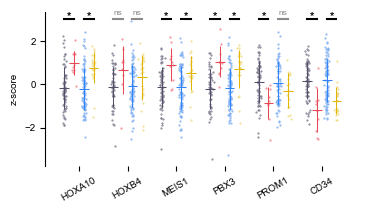

In [551]:
fig, ax = plt.subplots(
    figsize=(4, 2)
)

x_off = 0.2
bw = 0.1

#ax.axhline(c="k", lw=1., zorder=-1)

for x_center, gene in enumerate(hox2_prot):
    x_center = x_center + 1 - 1.5 * x_off
    for race in ["black", "white"]:
        for mut in ["WT", "NPM1"]:
            if (zs := zsf_prot.get((gene, race, mut))) is not None:
                ax.errorbar(
                    x_center,
                    np.mean(zs),
                    yerr=np.std(zs),
                    xerr=bw,
                    ecolor=C["bar"][(race, mut)],
                    elinewidth=0.75
                )
                # ax.scatter(
                #     x_center,
                #     np.mean(zs),
                #     marker="_",
                #     s=12,
                #     c="k",
                # )
                swarm(ax, x_center, zs, C["swarm"][(race, mut)])
            x_center += x_off
        # annotate statistically significant comparisons between WT and mutant
        bc = "#898989"
        t = "ns"
        t_yoff = 0.2
        fs = 6
        fw = "normal"
        if (pv := pvf_prot.get((gene, race))) is not None and pv <= 0.05:
            t = "*"
            bc = "k"
            t_yoff = 0
            fs = 8
            fw = "bold"
        ax.text(
            x_center - 1.5 * x_off,
            3 + t_yoff,
            t,
            color=bc,
            ha="center",
            fontsize=fs,
            fontweight=fw
        )
        ax.plot(
            [x_center - 2 * x_off, x_center - x_off],
            [3, 3],
            c=bc,
            ls="-",
            lw=1.5
        )


for d in ["top", "right", "bottom"]:
    ax.spines[d].set_visible(False)

ax.set_xticks([_ + 1 for _ in range(len(hox2_prot))])
ax.set_xticklabels(hox2_prot, rotation=30)

ax.set_ylabel("z-score")
plt.savefig(
    os.path.join(FIGURE_DIR, "z_score_bar_swarms_prot.png"),
    dpi=400,
    transparent=True,
    bbox_inches="tight"
)
plt.show()
plt.close()

---

In [389]:
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_FLT3-ITDxNPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    db_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_FLT3-ITDxNPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    db_mut_cols = mutf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_FLT3-ITDxNPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    dw_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_FLT3-ITDxNPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    dw_mut_cols = mutf.read().split("\n")

ddf = (
    pl.concat(
        [
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_FLT3-ITDxNPM1-WT.arrow"]).path),
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_FLT3-ITDxNPM1-WT.arrow"]).path)
        ], 
        how="diagonal"
    )
    .filter(pl.col("Block") == "Transcriptomics")
    .drop("Block")
    .rename({"Feature": "Gene"})
    .filter(
        pl.col("Gene").is_in(hox2)
    )
    .unpivot(
            index="Gene",
            variable_name="Sample",
            value_name="Z-score"
        )
        .with_columns(
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "WT"
                        for k in dw_wt_cols + db_wt_cols
                    } | {
                        k: "NPM1+FLT3_ITD"
                        for k in dw_mut_cols + db_mut_cols
                    }
                )
                .alias("Mutation")
            ),
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "black"
                        for k in db_wt_cols + db_mut_cols
                    } | {
                        k: "white"
                        for k in dw_wt_cols + dw_mut_cols
                    }
                )
                .alias("Race")
            )
        )
)
ddf

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_45920/753799656.py:1: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_FLT3-ITDxNPM1-WT_wt-cols.txt"]).path, "r") as wtf:


[syn74776632:B_FLT3-ITDxNPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/643/172720643/B_FLT3-ITDxNPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_45920/753799656.py:3: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_FLT3-ITDxNPM1-WT_mut-cols.txt"]).path, "r") as mutf:


[syn74776633:B_FLT3-ITDxNPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/644/172720644/B_FLT3-ITDxNPM1-WT_mut-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_45920/753799656.py:5: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["W_FLT3-ITDxNPM1-WT_wt-cols.txt"]).path, "r") as wtf:


...

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_45920/753799656.py:13: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_FLT3-ITDxNPM1-WT.arrow"]).path),


[syn74776644:B_FLT3-ITDxNPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/662/172720662/B_FLT3-ITDxNPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_45920/753799656.py:14: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_FLT3-ITDxNPM1-WT.arrow"]).path)


[syn74776658:W_FLT3-ITDxNPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/849/174033849/W_FLT3-ITDxNPM1-WT.arrow, skipping download.


Gene,Sample,Z-score,Mutation,Race
str,str,f64,str,str
"""HOXA9""","""14-00240""",null,"""WT""","""black"""
"""HOXA5""","""14-00240""",null,"""WT""","""black"""
"""HOXA6""","""14-00240""",null,"""WT""","""black"""
"""HOXB6""","""14-00240""",null,"""WT""","""black"""
"""HOXB5""","""14-00240""",null,"""WT""","""black"""
…,…,…,…,…
"""HOXA7""","""17-00025-Bridge""",null,"""NPM1+FLT3_ITD""","""white"""
"""MEIS1""","""17-00025-Bridge""",null,"""NPM1+FLT3_ITD""","""white"""
"""PBX3""","""17-00025-Bridge""",null,"""NPM1+FLT3_ITD""","""white"""


In [391]:
ddf_pan = (
    ddf
    .drop("Sample")
    .pivot(
        on=["Mutation", "Race"],
        values="Z-score",
        aggregate_function="mean",
    )
    .rename({
        '{"WT","black"}': "(black) NPM1-",
        '{"WT","white"}': "(white) NPM1-",
        '{"NPM1+FLT3_ITD","black"}': "(black) NPM1+/FLT3_ITD+",
        '{"NPM1+FLT3_ITD","white"}': "(white) NPM1+/FLT3_ITD+"
    })
    .to_pandas()
    .set_index("Gene")
)

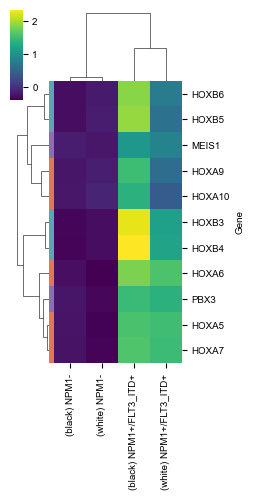

In [392]:
sns.clustermap(
    ddf_pan,
    row_colors=row_colors,
    cmap="viridis",
    figsize=(2.5, 5),
)
plt.savefig(
    os.path.join(FIGURE_DIR, "hox_heatmap_double-mutant.pdf"),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()

In [397]:
dzscores = (
    ddf
    .filter(pl.col("Z-score").is_not_null())
    .group_by("Gene", "Race", "Mutation")
    .agg("Z-score")
)
dzscores

Gene,Race,Mutation,Z-score
str,str,str,list[f64]
"""HOXA10""","""black""","""WT""","[-0.700615, -0.524345, … -0.580817]"
"""HOXB5""","""black""","""NPM1+FLT3_ITD""","[0.949489, 2.567619, … 1.983473]"
"""HOXB6""","""white""","""WT""","[-0.633869, -0.63607, … -0.637158]"
"""HOXA7""","""black""","""NPM1+FLT3_ITD""","[3.775012, 0.680374, … 3.600119]"
"""HOXA9""","""black""","""WT""","[-0.648055, -0.57072, … -0.620625]"
…,…,…,…
"""MEIS1""","""white""","""WT""","[-0.889636, -0.88993, … -0.877644]"
"""HOXB3""","""white""","""WT""","[-0.615455, -0.631484, … -0.631954]"
"""PBX3""","""black""","""NPM1+FLT3_ITD""","[2.546148, 1.443302, … 2.487012]"


In [394]:
dzsf = {
    (g, r, m): z
    for g, r, m, z in dzscores.iter_rows()
}

In [398]:
dpvf = {}
for gene in hox2:
    for race in ["black", "white"]:
        if (
            (zs_wt := dzsf.get((gene, race, "WT"))) is not None 
            and (zs_mut := dzsf.get((gene, race, "NPM1+FLT3_ITD"))) is not None
        ):
            dpvf[(gene, race)] = stats.ttest_ind(zs_wt, zs_mut, equal_var=False).pvalue

In [399]:
# apply BH correction to ttest pvalues
dpvf_keys, dpvf_values = map(list, zip(*dpvf.items()))
dpvf = dict(zip(dpvf_keys, stats.false_discovery_control(dpvf_values)))

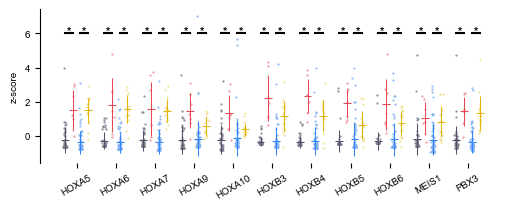

In [404]:
fig, ax = plt.subplots(
    figsize=(6, 2)
)

x_off = 0.2
bw = 0.1

#ax.axhline(c="k", lw=1., zorder=-1)

for x_center, gene in enumerate(hox2):
    x_center = x_center + 1 - 1.5 * x_off
    for race in ["black", "white"]:
        for mut in ["WT", "NPM1+FLT3_ITD"]:
            if (zs := dzsf.get((gene, race, mut))) is not None:
                ax.errorbar(
                    x_center,
                    np.mean(zs),
                    yerr=np.std(zs),
                    xerr=bw,
                    ecolor=C["bar"][(race, mut)],
                    elinewidth=0.75
                )
                # ax.scatter(
                #     x_center,
                #     np.mean(zs),
                #     marker="_",
                #     s=12,
                #     c="k",
                # )
                swarm(ax, x_center, zs, C["swarm"][(race, mut)])
            x_center += x_off
        # annotate statistically significant comparisons between WT and mutant
        bc = "#898989"
        t = "ns"
        t_yoff = 0.2
        fs = 6
        fw = "normal"
        if (pv := dpvf.get((gene, race))) is not None and pv <= 0.05:
            t = "*"
            bc = "k"
            t_yoff = 0
            fs = 8
            fw = "bold"
        ax.text(
            x_center - 1.5 * x_off,
            6 + t_yoff,
            t,
            color=bc,
            ha="center",
            fontsize=fs,
            fontweight=fw
        )
        ax.plot(
            [x_center - 2 * x_off, x_center - x_off],
            [6, 6],
            c=bc,
            ls="-",
            lw=1.5
        )

for d in ["top", "right", "bottom"]:
    ax.spines[d].set_visible(False)

ax.set_xticks([_ + 1 for _ in range(len(hox2))])
ax.set_xticklabels(hox2, rotation=30)

ax.set_ylabel("z-score")
plt.savefig(
    os.path.join(FIGURE_DIR, "z_score_bar_swarms_double-mutant.png"),
    dpi=400,
    transparent=True,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [411]:
ddf_prot = (
    pl.concat(
        [
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_FLT3-ITDxNPM1-WT.arrow"]).path),
            pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_FLT3-ITDxNPM1-WT.arrow"]).path)
        ], 
        how="diagonal"
    )
    .filter(pl.col("Block") == "Proteomics")
    .drop("Block")
    .rename({"Feature": "Gene"})
    .filter(
        pl.col("Gene").is_in(hox2_prot)
    )
    .unpivot(
            index="Gene",
            variable_name="Sample",
            value_name="Z-score"
        )
        .with_columns(
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "WT"
                        for k in dw_wt_cols + db_wt_cols
                    } | {
                        k: "NPM1+FLT3_ITD"
                        for k in dw_mut_cols + db_mut_cols
                    }
                )
                .alias("Mutation")
            ),
            (
                pl.col("Sample")
                .replace(
                    {
                        k: "black"
                        for k in db_wt_cols + db_mut_cols
                    } | {
                        k: "white"
                        for k in dw_wt_cols + dw_mut_cols
                    }
                )
                .alias("Race")
            )
        )
)
ddf_prot

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_45920/2822210250.py:4: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_FLT3-ITDxNPM1-WT.arrow"]).path),


[syn74776644:B_FLT3-ITDxNPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/662/172720662/B_FLT3-ITDxNPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_45920/2822210250.py:5: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_FLT3-ITDxNPM1-WT.arrow"]).path)


[syn74776658:W_FLT3-ITDxNPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/849/174033849/W_FLT3-ITDxNPM1-WT.arrow, skipping download.


Gene,Sample,Z-score,Mutation,Race
str,str,f64,str,str
"""CD34""","""14-00240""",-1.33872,"""WT""","""black"""
"""HOXA10""","""14-00240""",-0.815096,"""WT""","""black"""
"""HOXB4""","""14-00240""",-1.382941,"""WT""","""black"""
"""MEIS1""","""14-00240""",-0.988094,"""WT""","""black"""
"""PBX3""","""14-00240""",-1.276417,"""WT""","""black"""
…,…,…,…,…
"""HOXA10""","""17-00025-Bridge""",0.874429,"""NPM1+FLT3_ITD""","""white"""
"""HOXB4""","""17-00025-Bridge""",1.276025,"""NPM1+FLT3_ITD""","""white"""
"""MEIS1""","""17-00025-Bridge""",1.202422,"""NPM1+FLT3_ITD""","""white"""


In [412]:
dzscores_prot = (
    ddf_prot
    .filter(pl.col("Z-score").is_not_null())
    .group_by("Gene", "Race", "Mutation")
    .agg("Z-score")
)
dzscores_prot

Gene,Race,Mutation,Z-score
str,str,str,list[f64]
"""HOXB4""","""black""","""NPM1+FLT3_ITD""","[1.023507, 2.022835, … 0.00094]"
"""PROM1""","""white""","""NPM1+FLT3_ITD""","[-0.310373, -0.743564, … -1.128762]"
"""PROM1""","""black""","""WT""","[-1.14532, -0.477048, … 1.02204]"
"""HOXA10""","""white""","""NPM1+FLT3_ITD""","[1.534274, 1.406542, … 0.874429]"
"""HOXB4""","""white""","""WT""","[-0.100841, 0.627863, … 0.5356]"
…,…,…,…
"""PROM1""","""white""","""WT""","[0.385171, 1.036362, … -0.567403]"
"""CD34""","""white""","""WT""","[0.555741, -0.65927, … -0.114666]"
"""PBX3""","""black""","""WT""","[-1.276417, -0.196113, … -1.02482]"


In [413]:
dzsf_prot = {
    (g, r, m): z
    for g, r, m, z in dzscores_prot.iter_rows()
}

In [414]:
dpvf_prot = {}
for gene in hox2_prot:
    for race in ["black", "white"]:
        if (
            (zs_wt := dzsf_prot.get((gene, race, "WT"))) is not None 
            and (zs_mut := dzsf_prot.get((gene, race, "NPM1+FLT3_ITD"))) is not None
        ):
            dpvf_prot[(gene, race)] = stats.ttest_ind(zs_wt, zs_mut, equal_var=False).pvalue

In [415]:
# apply BH correction to ttest pvalues
dpvf_prot_keys, dpvf_prot_values = map(list, zip(*dpvf_prot.items()))
dpvf_prot = dict(zip(dpvf_prot_keys, stats.false_discovery_control(dpvf_prot_values)))

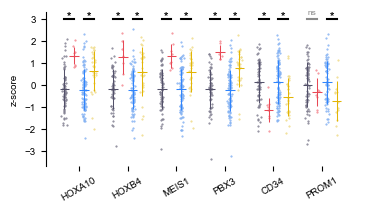

In [416]:
fig, ax = plt.subplots(
    figsize=(4, 2)
)

x_off = 0.2
bw = 0.1

#ax.axhline(c="k", lw=1., zorder=-1)

for x_center, gene in enumerate(hox2_prot):
    x_center = x_center + 1 - 1.5 * x_off
    for race in ["black", "white"]:
        for mut in ["WT", "NPM1+FLT3_ITD"]:
            if (zs := dzsf_prot.get((gene, race, mut))) is not None:
                ax.errorbar(
                    x_center,
                    np.mean(zs),
                    yerr=np.std(zs),
                    xerr=bw,
                    ecolor=C["bar"][(race, mut)],
                    elinewidth=0.75
                )
                # ax.scatter(
                #     x_center,
                #     np.mean(zs),
                #     marker="_",
                #     s=12,
                #     c="k",
                # )
                swarm(ax, x_center, zs, C["swarm"][(race, mut)])
            x_center += x_off
        # annotate statistically significant comparisons between WT and mutant
        bc = "#898989"
        t = "ns"
        t_yoff = 0.2
        fs = 6
        fw = "normal"
        if (pv := dpvf_prot.get((gene, race))) is not None and pv <= 0.05:
            t = "*"
            bc = "k"
            t_yoff = 0
            fs = 8
            fw = "bold"
        ax.text(
            x_center - 1.5 * x_off,
            3 + t_yoff,
            t,
            color=bc,
            ha="center",
            fontsize=fs,
            fontweight=fw
        )
        ax.plot(
            [x_center - 2 * x_off, x_center - x_off],
            [3, 3],
            c=bc,
            ls="-",
            lw=1.5
        )


for d in ["top", "right", "bottom"]:
    ax.spines[d].set_visible(False)

ax.set_xticks([_ + 1 for _ in range(len(hox2_prot))])
ax.set_xticklabels(hox2_prot, rotation=30)

ax.set_ylabel("z-score")
plt.savefig(
    os.path.join(FIGURE_DIR, "z_score_bar_swarms_prot_double-mutant.png"),
    dpi=400,
    transparent=True,
    bbox_inches="tight"
)
plt.show()
plt.close()